In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/makam.xlsx'
df = pd.read_excel(file_path)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),TDS\n(mg/L),Salinity\n(g/L),DO\n(mg/L),Sensor Depth\n(m),pH,Chlorophyll\n(ug/L),Turbid\n(NTU)
0,2014-04-28 14:40:00,28.93,0.0,20.0,0.01,7.87,0.96,9.34,1.10,4.50
1,2014-04-28 14:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-04-28 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-04-28 15:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-04-28 15:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.72,260.0,166.5,0.12,3.27,2.02,0.00,6.70,49.64
538749,2024-07-25 22:10:00,30.71,260.0,166.4,0.12,3.35,2.06,0.00,5.86,40.77
538750,2024-07-25 22:20:00,30.71,258.0,165.5,0.12,3.24,2.10,0.00,2.97,55.74
538751,2024-07-25 22:30:00,30.71,258.0,165.3,0.12,3.30,2.13,0.00,5.18,47.67


In [ ]:
df = df.drop(['TDS\n(mg/L)'], axis=1)
df = df.drop(['Salinity\n(g/L)'], axis=1)
df = df.drop(['Sensor Depth\n(m)'], axis=1)
df = df.drop(['Chlorophyll\n(ug/L)'], axis=1)
df = df.drop(['Turbid\n(NTU)'], axis=1)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
0,2014-04-28 14:40:00,28.93,0.0,7.87,9.34
1,2014-04-28 14:50:00,NaN,NaN,NaN,NaN
2,2014-04-28 15:00:00,NaN,NaN,NaN,NaN
3,2014-04-28 15:10:00,NaN,NaN,NaN,NaN
4,2014-04-28 15:20:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.72,260.0,3.27,0.00
538749,2024-07-25 22:10:00,30.71,260.0,3.35,0.00
538750,2024-07-25 22:20:00,30.71,258.0,3.24,0.00
538751,2024-07-25 22:30:00,30.71,258.0,3.30,0.00


In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,432899.000000,432899.000000,432899.000000,432899.000000
mean,2019-06-12 06:39:59.999998464,-78.213296,349.596384,-210.651016,-398.025160
min,2014-04-28 14:40:00,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,2016-11-18 22:40:00,29.140000,294.000000,1.630000,7.120000
50%,2019-06-12 06:40:00,30.550000,356.000000,2.720000,7.230000
75%,2022-01-02 14:40:00,31.410000,440.000000,3.600000,7.340000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,1037.028654,1173.119092,1445.086492,1972.434922


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),105854
Conductivity\n(uS/cm),105854
DO\n(mg/L),105854
pH,105854


In [ ]:
# ตรวจสอบค่า -9999 ในทุกคอลัมน์
neg9999_counts = (df == -9999).sum()
print(neg9999_counts)

date_time                    0
Temperature\n(֯C)         4679
Conductivity\n(uS/cm)     4658
DO\n(mg/L)                9234
pH                       17531
dtype: int64


In [ ]:
df = df.replace(-9999, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,428220.000000,428241.000000,423665.000000,415368.000000
mean,2019-06-12 06:39:59.999998464,30.187435,462.158614,2.691163,7.193080
min,2014-04-28 14:40:00,0.000000,-3999.000000,0.000000,-26.300000
25%,2016-11-18 22:40:00,29.190000,297.000000,1.730000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.760000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.620000,7.350000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,2.339895,462.215793,1.578567,0.650542


In [ ]:
# ตรวจสอบค่า 0 ในทุกคอลัมน์
zero_counts = (df == 0).sum()
print(zero_counts)

date_time                    0
Temperature\n(֯C)          597
Conductivity\n(uS/cm)     2263
DO\n(mg/L)               42510
pH                        2794
dtype: int64


In [ ]:
df = df.replace(0, np.nan)

In [ ]:
zero_counts = (df == 50.840000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(50.840000, np.nan)

In [ ]:
zero_counts = (df == -26.300000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(-26.300000, np.nan)

In [ ]:
zero_counts = (df == -3999.000000).sum()
print(zero_counts)

date_time                 0
Temperature\n(֯C)         0
Conductivity\n(uS/cm)    87
DO\n(mg/L)                0
pH                        0
dtype: int64


In [ ]:
df = df.replace(-3999.000000, np.nan)

In [ ]:
zero_counts = (df == 99.990000).sum()
print(zero_counts)

date_time                  0
Temperature\n(֯C)        105
Conductivity\n(uS/cm)      0
DO\n(mg/L)                 0
pH                         0
dtype: int64


In [ ]:
df = df.replace(99.990000, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425891.000000,381155.000000,412572.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.525639,2.991307,7.241768
min,2014-04-28 14:40:00,12.830000,1.000000,0.010000,-15.340000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.832389,1.368198,0.256849


In [ ]:
df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
df['pH'][df['pH'] < 1] = np.nan

<ipython-input-22-096c18d0bb55>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
<ipython-input-22-096c18d0bb55>:1: SettingWithCopyWarning: 
A value is trying to be set 

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412556.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.242067
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.834400,1.368198,0.251171


In [ ]:
df['pH'][df['pH'] > 14] = np.nan

<ipython-input-24-796f110e6a72>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pH'][df['pH'] > 14] = np.nan
<ipython-input-24-796f110e6a72>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame



In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412552.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.241943
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.736159,457.834400,1.368198,0.247345


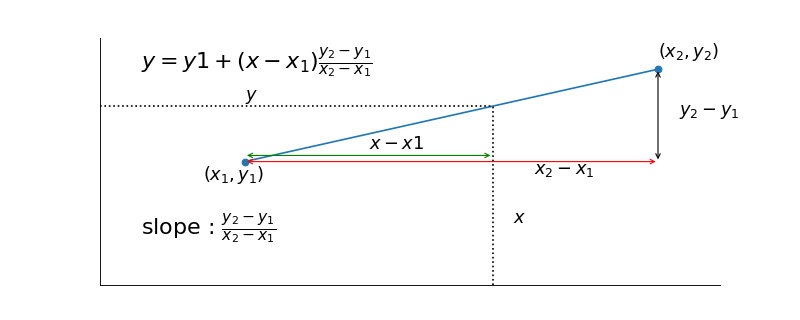

In [ ]:
df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
df['Conductivity\n(uS/cm)'].interpolate(method='linear', inplace=True)
df['DO\n(mg/L)'].interpolate(method='linear', inplace=True)
df['pH'].interpolate(method='linear', inplace=True)

<ipython-input-26-b4db06670e76>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
<ipython-input-26-b4db06670e76>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,536313.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.000000,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,524.967900,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,426.525651,1.217890,0.353856


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),2440
DO\n(mg/L),0
pH,0


In [ ]:
df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)

<ipython-input-29-0624677d0968>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),0
DO\n(mg/L),0
pH,0


In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,538753.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.654009,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,523.263959,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,425.558691,1.217890,0.353856


In [ ]:
# แปลงคอลัมน์ date_time เป็น datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

In [ ]:
df = df.set_index('date_time')

In [ ]:
df = df.resample('D').mean()

In [ ]:
df.describe()

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,3742.000000,3742.000000,3742.000000,3742.000000
mean,30.082841,501.197137,2.964834,7.236713
std,1.604176,359.352210,1.112831,0.345785
min,20.238053,164.506944,0.233403,2.082611
25%,29.155968,318.486111,2.331814,7.160433
50%,30.205885,386.133681,2.907473,7.261844
75%,31.246372,539.541667,3.466858,7.340180
max,34.226458,4057.263889,7.837917,9.276510


# Data

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510
2014-04-29,29.433154,501.199898,7.346309,9.045638
2014-04-30,30.001423,501.199898,6.754846,8.713181
2014-05-01,30.569691,501.199898,6.163383,8.380725
2014-05-02,31.137960,501.199898,5.571919,8.048268
...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000
2024-07-22,31.287986,345.090278,2.114375,3.080000
2024-07-23,31.137361,338.798611,2.126111,3.080000


In [ ]:
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

https://medium.com/datawiz-th/%E0%B8%A1%E0%B8%B2%E0%B8%A5%E0%B8%AD%E0%B8%87-forecast-%E0%B8%A3%E0%B8%B2%E0%B8%84%E0%B8%B2%E0%B8%AB%E0%B8%B8%E0%B9%89%E0%B8%99%E0%B9%81%E0%B8%9A%E0%B8%9A%E0%B8%87%E0%B9%88%E0%B8%B2%E0%B8%A2%E0%B9%86-%E0%B8%94%E0%B9%89%E0%B8%A7%E0%B8%A2-deep-learning-lstm-python-305c480db223

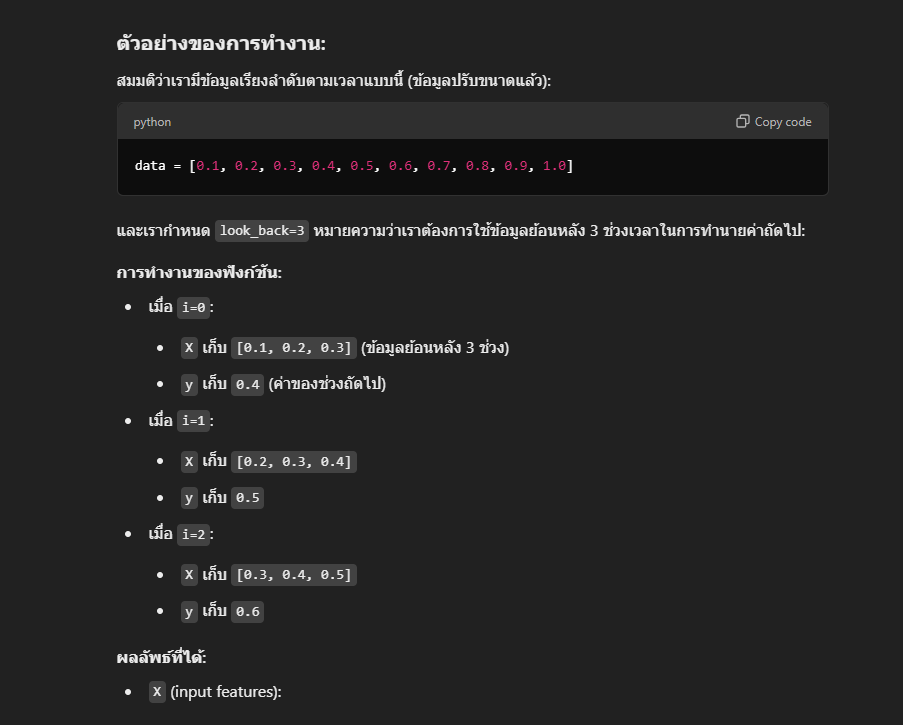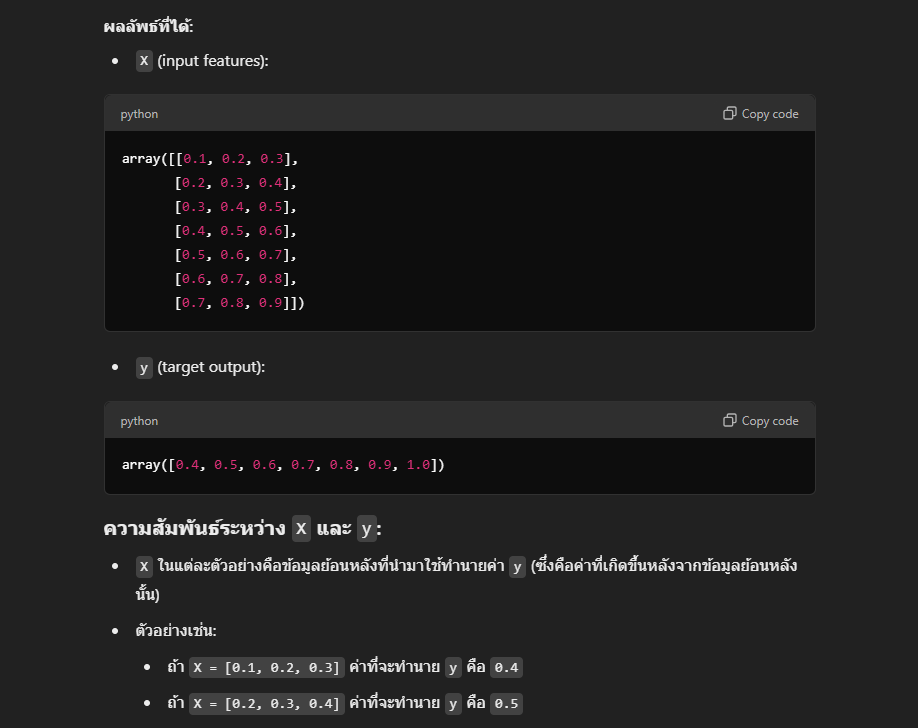

In [ ]:
df[:10]

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510
2014-04-29,29.433154,501.199898,7.346309,9.045638
2014-04-30,30.001423,501.199898,6.754846,8.713181
2014-05-01,30.569691,501.199898,6.163383,8.380725
2014-05-02,31.137960,501.199898,5.571919,8.048268
2014-05-03,31.678415,501.199898,4.928164,7.711670
2014-05-04,31.693750,501.199898,4.448542,7.597917
2014-05-05,31.747917,501.199898,4.301528,7.620000
2014-05-06,31.799965,501.199898,4.414688,7.693785


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Temperature\n(֯C)']])

In [ ]:
look_back = 7 #ย้อนหลัง 7 วันมาเทรนข้อมูล
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (3735, 7, 1)
Shape of y: (3735,)


In [ ]:

print("X:")
print(X[:5])

# แสดงค่า y แถวแรก 5 แถว
print("\n y:")
print(y[:5])


X:
[[[0.62912608]
  [0.65733737]
  [0.69796161]
  [0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]]

 [[0.65733737]
  [0.69796161]
  [0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]]

 [[0.69796161]
  [0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]
  [0.82653541]]

 [[0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]
  [0.82653541]
  [0.82480531]]

 [[0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]
  [0.82653541]
  [0.82480531]
  [0.83715681]]]

 y:
[0.82281457 0.82653541 0.82480531 0.83715681 0.84707574]


In [ ]:
def train_and_evaluate_lstm(X_train, y_train, X_test, y_test, look_back, epochs=20, batch_size=16):

    # สร้างโมเดล LSTM
    model = Sequential()


    # LSTM ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1),
                   kernel_regularizer=regularizers.l2(0.001)))  # L2 Regularization
    model.add(Dropout(0.4))  # Dropout ที่ 0.3

    # Batch Normalization หลังจาก LSTM ชั้นแรก
    model.add(BatchNormalization())

    # LSTM ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(LSTM(50, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.4))  # Dropout ที่ 0.3

     # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.4))


    model.add(Dense(1))  # Output layer
    optimizer = RMSprop(learning_rate=0.0005)
    model.compile(optimizer='adam', loss='mean_squared_error')

    # เพิ่ม EarlyStopping เพื่อตรวจจับการ overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)



    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()


    predictions = model.predict(X_test)


    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")
    #print(f"y_test: {y_test}")
    #print(f"predictions: {predictions}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics

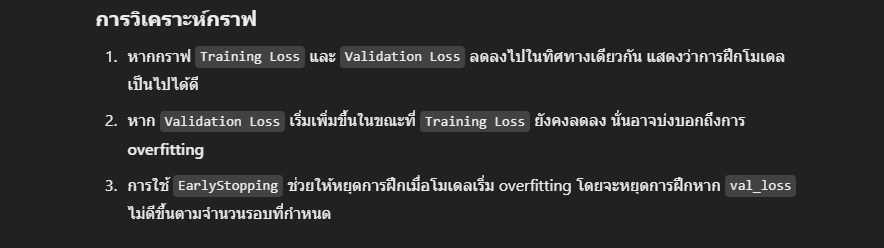

In [ ]:
def split_and_train_lstm(X, y, look_back, num_splits=3, epochs=20, batch_size=16):
    split_size = int(len(X) * 0.7)
    split_increment = int((len(X) - split_size) / num_splits)
    models = []
    metrics_list = []


    for i in range(num_splits):
        split_at = split_size + i * split_increment


        X_train = X[i * split_increment:split_at]
        X_test  = np.concatenate((X[:i * split_increment], X[split_at:]), axis=0)
        y_train = y[i * split_increment:split_at]
        y_test  = np.concatenate((y[:i * split_increment], y[split_at:]), axis=0)

        print(f"\n--- Training round {i+1} ---")
        print(f"Training data size: {X_train.shape}, Testing data size: {X_test.shape}")


        model, predictions, metrics = train_and_evaluate_lstm(X_train, y_train, X_test, y_test, look_back, epochs=epochs, batch_size=batch_size)


        models.append(model)
        metrics_list.append(metrics)

    return models, metrics_list



#**Temp**


--- Training round 1 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.2257 - val_loss: 0.2048
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1070 - val_loss: 0.1412
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0766 - val_loss: 0.0696
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0539 - val_loss: 0.0359
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0392 - val_loss: 0.0217
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0283 - val_loss: 0.0190
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0205 - val_loss: 0.0118
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0160 - val_loss: 0.0103
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0123 - val_loss: 0.0082
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0095 - val_loss: 0.0070
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0077 - val_loss: 0.0049
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms

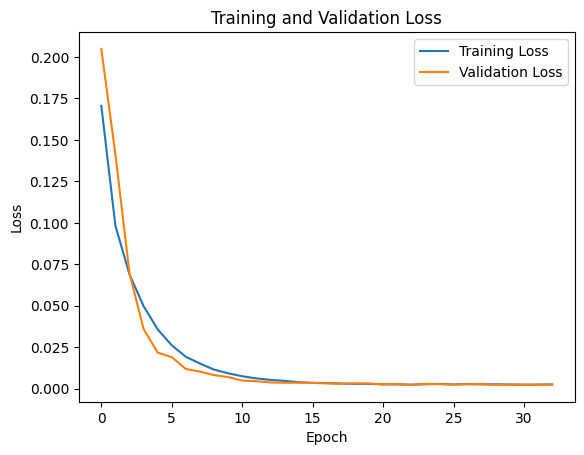

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
R2: 0.8859019805588244
MAE: 0.026389219382569634
RMSE: 0.044392224320723705
MSE: 0.001970669580141453

--- Training round 2 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2600 - val_loss: 0.1935
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1075 - val_loss: 0.0953
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0728 - val_loss: 0.0625
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0525 - val_loss: 0.0372
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0364 - val_loss: 0.0268
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0254 - val_loss: 0.0137
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0200 - val_loss: 0.0102
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0155 - val_loss: 0.0096
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0121 - val_loss: 0.0065
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0096 - val_loss: 0.0058
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0079 - val_loss: 0.0046
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss:

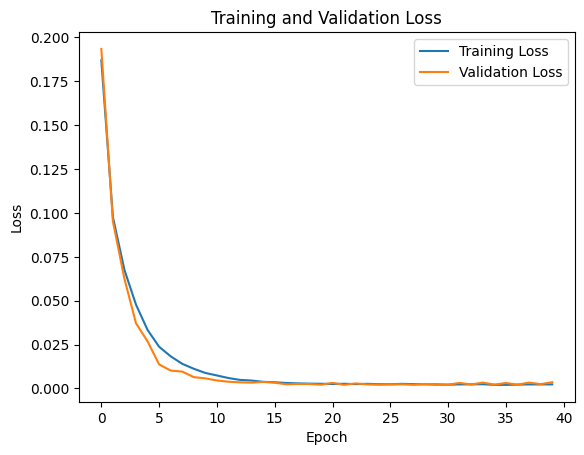

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
R2: 0.9042642574789365
MAE: 0.02309985305350083
RMSE: 0.04189896490416414
MSE: 0.0017555232600403787

--- Training round 3 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2533 - val_loss: 0.1516
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1023 - val_loss: 0.0792
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0699 - val_loss: 0.0638
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0490 - val_loss: 0.0299
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0367 - val_loss: 0.0241
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0261 - val_loss: 0.0119
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0203 - val_loss: 0.0099
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0147 - val_loss: 0.0073
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0120 - val_loss: 0.0061
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0100 - val_loss: 0.0047
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0078 - val_loss: 0.0037
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - los

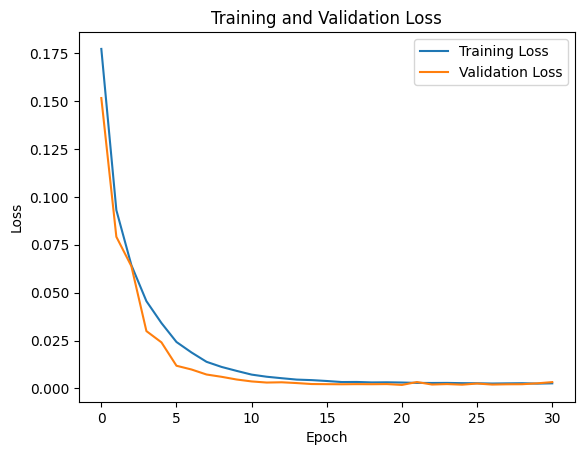

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
R2: 0.8801465760055672
MAE: 0.017451247717335135
RMSE: 0.03871742497176619
MSE: 0.0014990389964443442


In [ ]:
models, metrics_list = split_and_train_lstm(X, y, look_back=7, num_splits=3, epochs=50, batch_size=16)

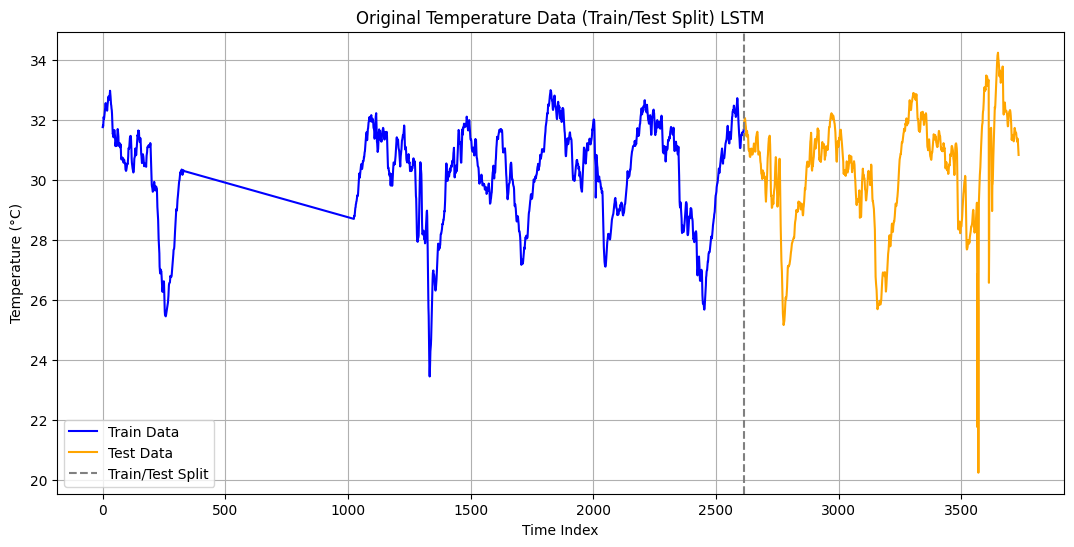

In [ ]:
# กลับค่า y เป็นสเกลจริง
y_inv = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

plt.figure(figsize=(13, 6))

# ข้อมูล Train/Test ที่ใช้ในรอบล่าสุด
split_at = int(len(y) * 0.7)

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(range(split_at), y_train_inv, label="Train Data", color='blue')
plt.plot(range(split_at, len(y_inv)), y_test_inv, label="Test Data", color='orange')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Original Temperature Data (Train/Test Split) LSTM")
plt.xlabel("Time Index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


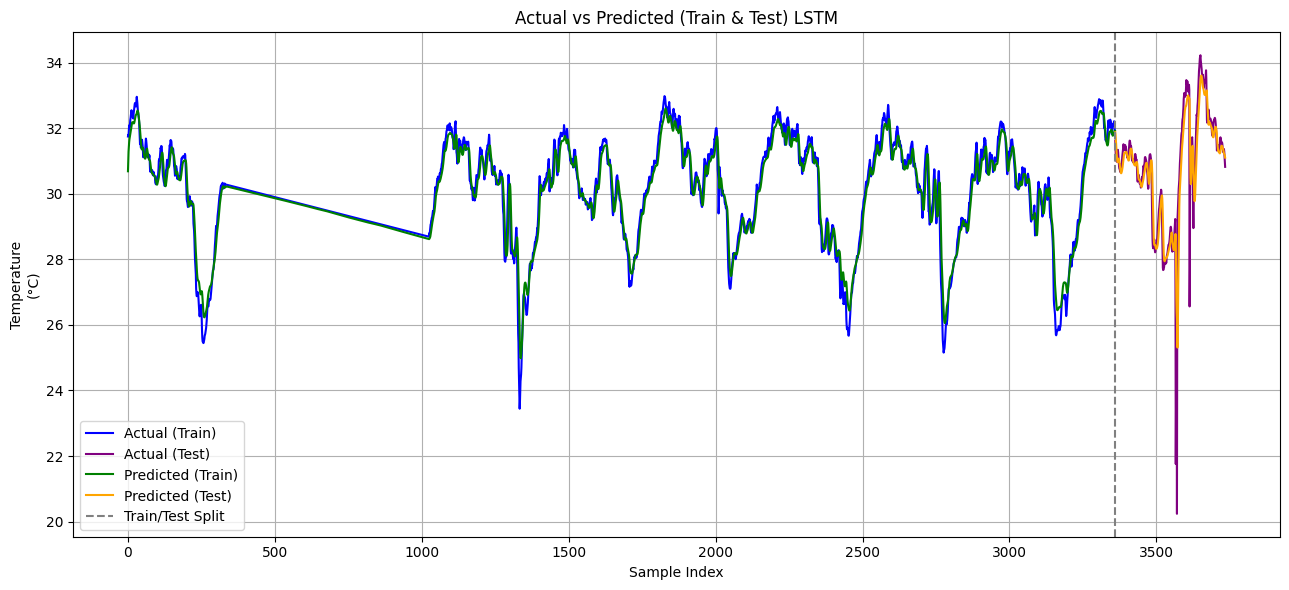

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ค่าจริงแบบคืนค่าจาก scale
y_all = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

# เลือกโมเดลที่ดีที่สุดจากรายการ
best_model_index = 0  # คุณสามารถเปลี่ยนเป็น 1 หรือ 2 หากต้องการใช้โมเดลอื่น
selected_model = models[best_model_index]

# นำข้อมูลเทรนและเทสจากผลลัพธ์การแบ่งข้อมูลที่มีอยู่แล้ว
# สมมติว่าโค้ดต้นฉบับมีการแบ่งข้อมูลและเก็บไว้ในตัวแปร X_train1 และ X_test1
X_train1 = X[:split_at]
X_test1 = X[split_at:]

# ค่าทำนายช่วงเทรน
y_pred_train = selected_model.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = selected_model.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv

# วาดกราฟ
plt.figure(figsize=(13, 6))

# สร้าง index สำหรับการพล็อต (เนื่องจาก y เป็น numpy array ไม่มี index)
index_range = np.arange(len(y_all))
train_indices = index_range[:split_at]
test_indices = index_range[split_at:]

plt.plot(train_indices, y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(test_indices, y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(train_indices, y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(test_indices, y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) LSTM")
plt.xlabel("Sample Index")
plt.ylabel("Temperature\n(°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

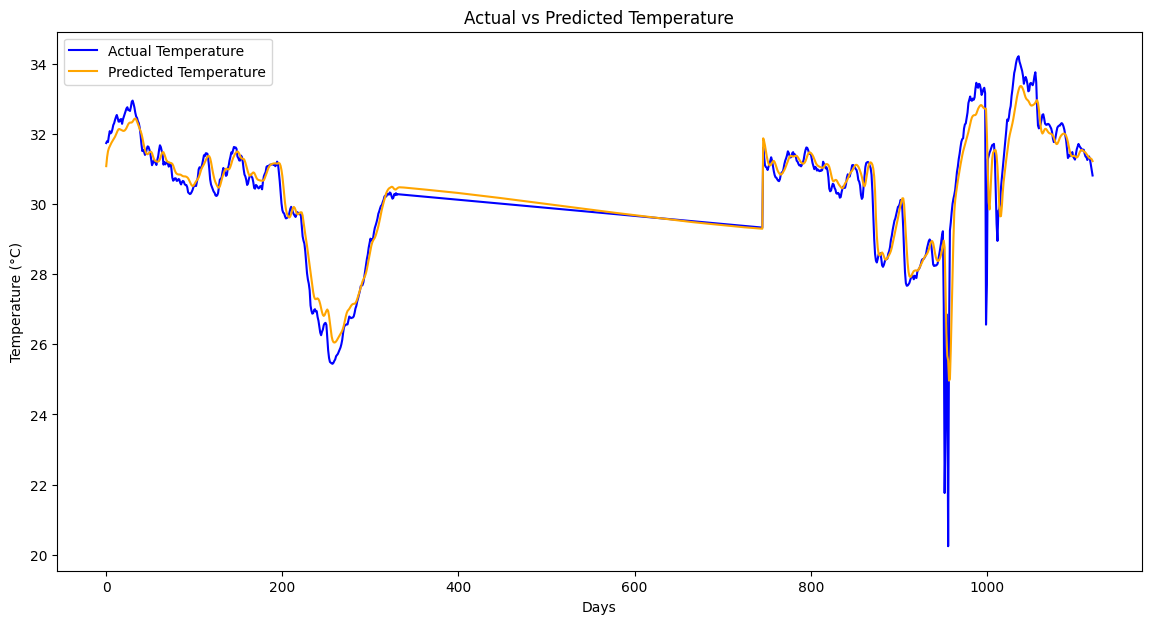

In [ ]:

# ตัวยอย่างค่าจริงและค่าทำนายจากโมเดลสุดท้าย
predictions_last_model = metrics_list[-1]['predictions']
y_test_last_model = metrics_list[-1]['y_test']

# แปลงค่าทำนายกลับไปยังหน่วยเดิม
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model.reshape(-1, 1))

# วาดกราฟ
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual Temperature', color='blue')
plt.plot(predictions_last_model, label='Predicted Temperature', color='orange')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


In [ ]:
predictions_last_model

array([[31.088259],
       [31.345201],
       [31.511406],
       ...,
       [31.305655],
       [31.283636],
       [31.233303]], dtype=float32)

In [ ]:
y_test_last_model

array([[31.74791667],
       [31.79996528],
       [31.77576389],
       ...,
       [31.13736111],
       [30.96784722],
       [30.82160584]])

# **EC**

In [ ]:
def train_and_evaluate_lstm(X_train, y_train, X_test, y_test, look_back, epochs=20, batch_size=16):

    # สร้างโมเดล LSTM
    model = Sequential()


    # LSTM ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1),
                   kernel_regularizer=regularizers.l2(0.001)))  # L2 Regularization
    model.add(Dropout(0.25))

    # Batch Normalization หลังจาก LSTM ชั้นแรก
    model.add(BatchNormalization())

    # LSTM ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(LSTM(50, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.25))

     # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.3))


    model.add(Dense(1))  # Output layer
    optimizer = RMSprop(learning_rate=0.0005)
    model.compile(optimizer='adam', loss='mean_squared_error')

    # เพิ่ม EarlyStopping เพื่อตรวจจับการ overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)



    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()


    predictions = model.predict(X_test)


    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")
    #print(f"y_test: {y_test}")
    #print(f"predictions: {predictions}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Conductivity\n(uS/cm)']])

In [ ]:
look_back = 7
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


--- Training round 1 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0624 - val_loss: 0.0199
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0162 - val_loss: 0.0092
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0092 - val_loss: 0.0055
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0064 - val_loss: 0.0033
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0043 - val_loss: 0.0024
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0033 - val_loss: 0.0014
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 10/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0035 - val_loss: 0.0013
Epoch 11/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 12/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11

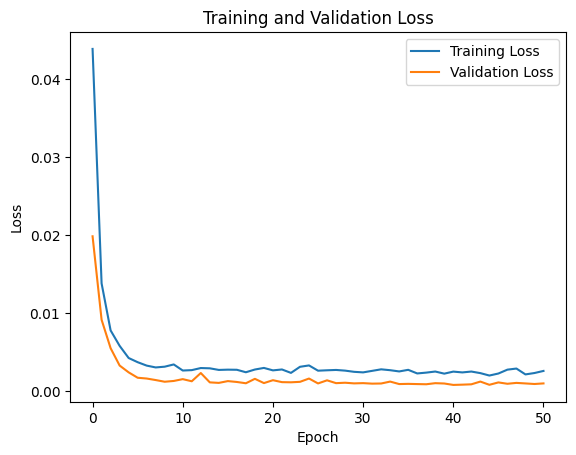

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
R2: 0.8715513961102815
MAE: 0.013142842071284107
RMSE: 0.021485091880993828
MSE: 0.00046160917313474686

--- Training round 2 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0647 - val_loss: 0.0212
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0187 - val_loss: 0.0110
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0103 - val_loss: 0.0058
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0069 - val_loss: 0.0035
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0049 - val_loss: 0.0024
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048 - val_loss: 0.0017
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 10/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0035 - val_loss: 0.0011
Epoch 11/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0038 - val_loss: 9.9892e-04
Epoch 12/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9

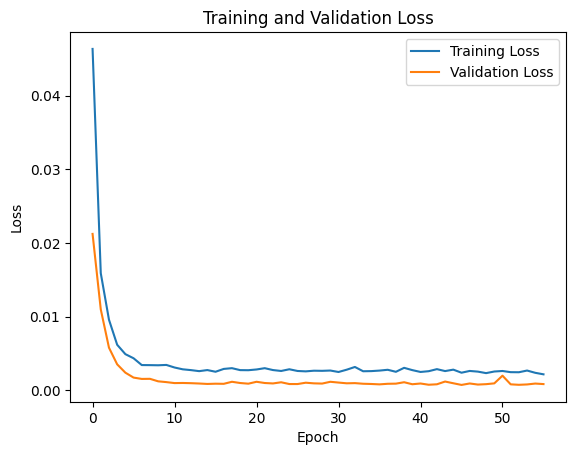

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
R2: 0.8382693217654558
MAE: 0.012661702991621662
RMSE: 0.019317464820271208
MSE: 0.00037316444708241573

--- Training round 3 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0622 - val_loss: 0.0186
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0165 - val_loss: 0.0088
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0092 - val_loss: 0.0051
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0059 - val_loss: 0.0032
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0048 - val_loss: 0.0020
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0039 - val_loss: 0.0018
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0032 - val_loss: 0.0021
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0032 - val_loss: 0.0010
Epoch 10/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 11/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0032 - val_loss: 0.0011
Epoch 12/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/s

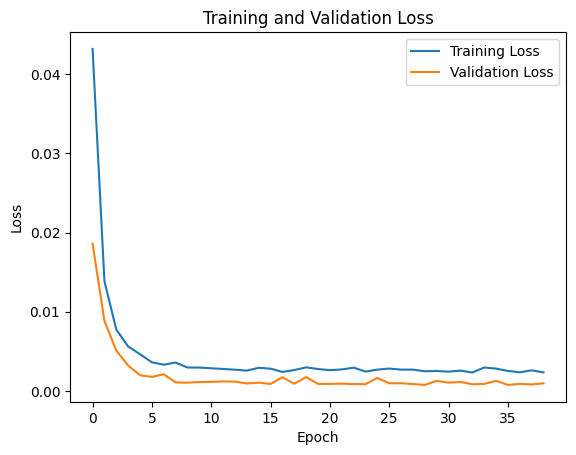

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
R2: 0.8595401544898738
MAE: 0.012757643800511578
RMSE: 0.019377056803619782
MSE: 0.0003754703303707077


In [ ]:
models, metrics_list = split_and_train_lstm(X, y, look_back=7, num_splits=3, epochs=100, batch_size=16)

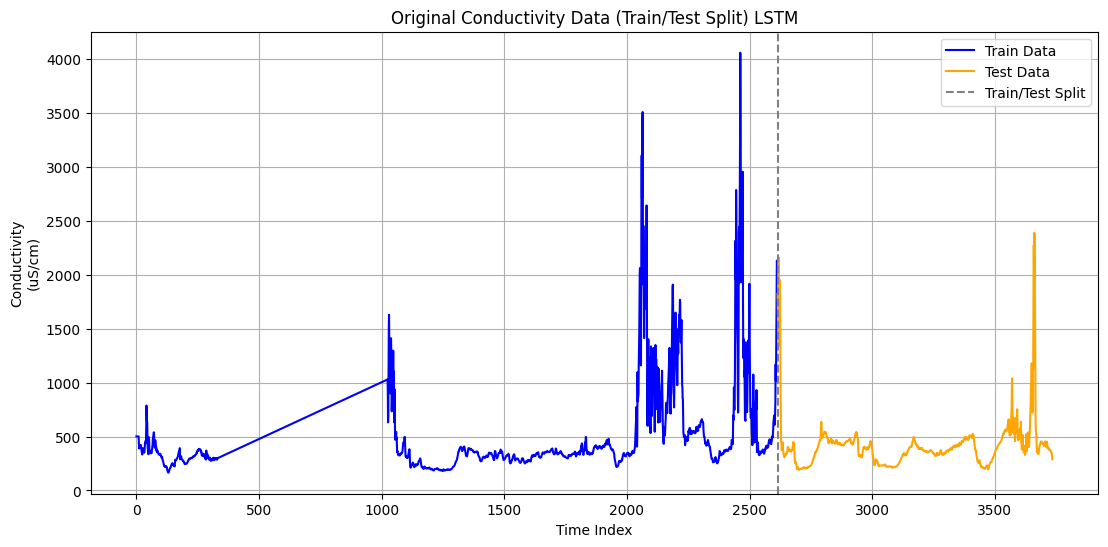

In [ ]:
# กลับค่า y เป็นสเกลจริง
y_inv = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

plt.figure(figsize=(13, 6))

# ข้อมูล Train/Test ที่ใช้ในรอบล่าสุด
split_at = int(len(y) * 0.7)

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(range(split_at), y_train_inv, label="Train Data", color='blue')
plt.plot(range(split_at, len(y_inv)), y_test_inv, label="Test Data", color='orange')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Original Conductivity Data (Train/Test Split) LSTM")
plt.xlabel("Time Index")
plt.ylabel("Conductivity\n(uS/cm)")
plt.legend()
plt.grid(True)
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


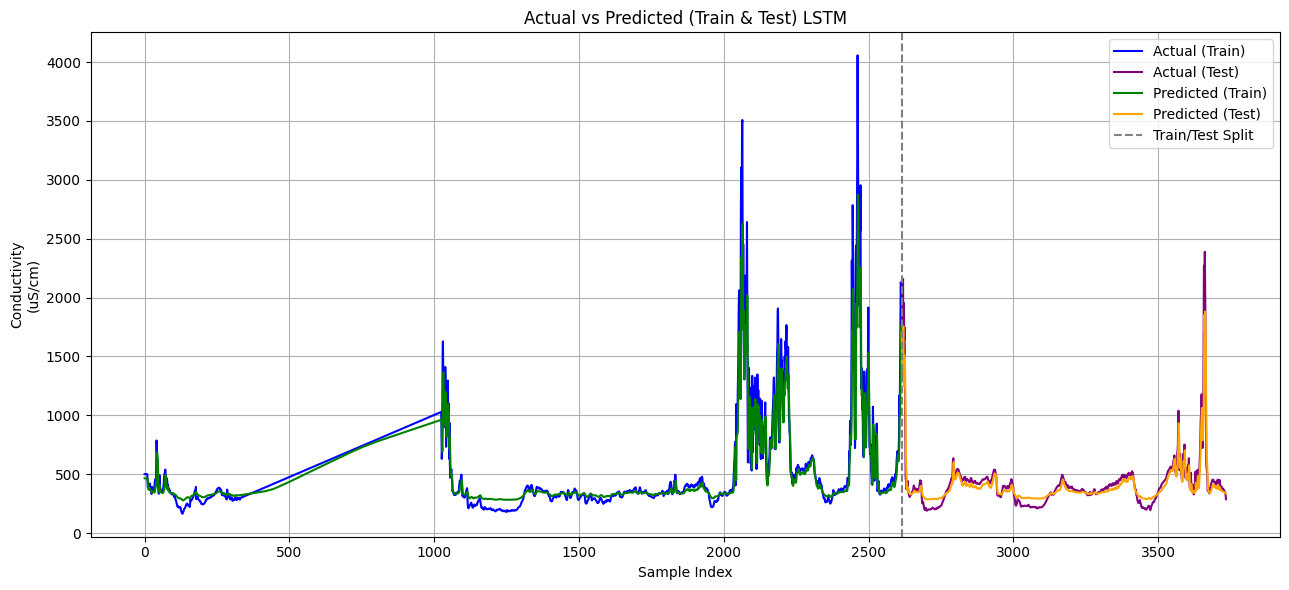

In [ ]:
# ค่าจริงแบบคืนค่าจาก scale
y_all = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

# เลือกโมเดลที่ดีที่สุดจากรายการ
best_model_index = 0  # คุณสามารถเปลี่ยนเป็น 1 หรือ 2 หากต้องการใช้โมเดลอื่น
selected_model = models[best_model_index]

# นำข้อมูลเทรนและเทสจากผลลัพธ์การแบ่งข้อมูลที่มีอยู่แล้ว
# สมมติว่าโค้ดต้นฉบับมีการแบ่งข้อมูลและเก็บไว้ในตัวแปร X_train1 และ X_test1
X_train1 = X[:split_at]
X_test1 = X[split_at:]

# ค่าทำนายช่วงเทรน
y_pred_train = selected_model.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = selected_model.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv

# วาดกราฟ
plt.figure(figsize=(13, 6))

# สร้าง index สำหรับการพล็อต (เนื่องจาก y เป็น numpy array ไม่มี index)
index_range = np.arange(len(y_all))
train_indices = index_range[:split_at]
test_indices = index_range[split_at:]

plt.plot(train_indices, y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(test_indices, y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(train_indices, y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(test_indices, y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) LSTM")
plt.xlabel("Sample Index")
plt.ylabel("Conductivity\n(uS/cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

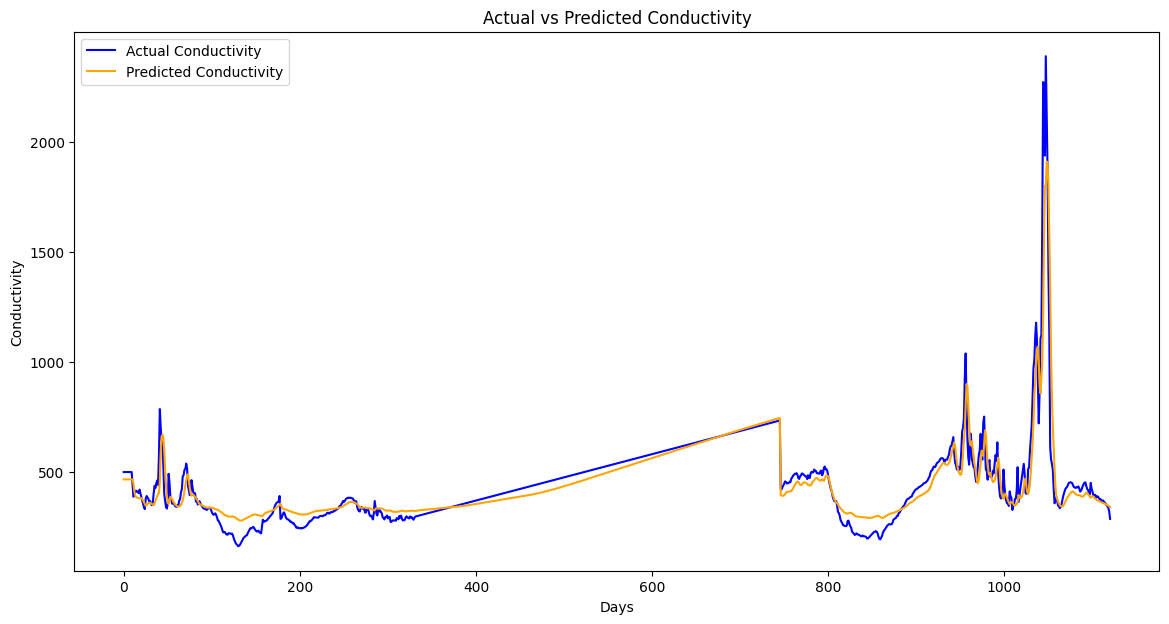

In [ ]:
predictions_last_model = metrics_list[-1]['predictions']
y_test_last_model = metrics_list[-1]['y_test']
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model.reshape(-1, 1))
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual Conductivity', color='blue')
plt.plot(predictions_last_model, label='Predicted Conductivity', color='orange')
plt.title('Actual vs Predicted Conductivity')
plt.xlabel('Days')
plt.ylabel('Conductivity')
plt.legend()
plt.show()

# **DO**

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
import matplotlib.pyplot as plt

def train_and_evaluate_lstm(X_train, y_train, X_test, y_test, look_back, epochs=50, batch_size=16):

    model = Sequential()

    # LSTM ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(LSTM(20, return_sequences=True, input_shape=(look_back, 1), kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.3))

    # Batch Normalization หลังจาก LSTM ชั้นแรก
    model.add(BatchNormalization())

    # LSTM ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(LSTM(20, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.3))

    # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.4))

    model.add(Dense(1))  # Output layer

    # ปรับค่า Learning Rate ของ Adam optimizer
    optimizer = Adam(learning_rate=0.0001)  # ปรับ learning rate ขึ้นเป็น 0.0001
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # เพิ่ม EarlyStopping และ Learning Rate Scheduling
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

    # ฝึกโมเดล
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop, reduce_lr])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    # ทำการทำนาย
    predictions = model.predict(X_test)

    # คำนวณ metrics
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['DO\n(mg/L)']])

In [ ]:
look_back = 7
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


--- Training round 1 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2767 - val_loss: 0.1431 - learning_rate: 1.0000e-04
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1471 - val_loss: 0.0858 - learning_rate: 1.0000e-04
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1046 - val_loss: 0.0646 - learning_rate: 1.0000e-04
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0902 - val_loss: 0.0581 - learning_rate: 1.0000e-04
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0841 - val_loss: 0.0560 - learning_rate: 1.0000e-04
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0754 - val_loss: 0.0546 - learning_rate: 1.0000e-04
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0712 - val_loss: 0.0533 - learning_rate: 1.0000e-04
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0676 - val_loss: 0.0518 - learning_rate: 1.0000e-04
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0634 - val_loss: 0.0495 - 

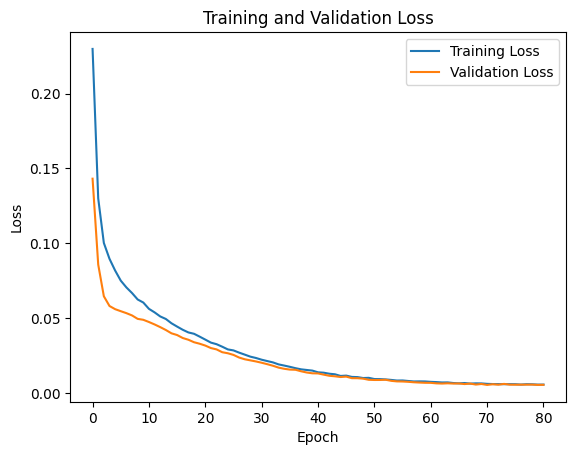

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.9021642474075202
MAE: 0.04153293007460326
RMSE: 0.06016537953871121
MSE: 0.0036198728950371695

--- Training round 2 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1753 - val_loss: 0.1421 - learning_rate: 1.0000e-04
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1123 - val_loss: 0.1077 - learning_rate: 1.0000e-04
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0967 - val_loss: 0.0843 - learning_rate: 1.0000e-04
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0862 - val_loss: 0.0723 - learning_rate: 1.0000e-04
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0776 - val_loss: 0.0623 - learning_rate: 1.0000e-04
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0733 - val_loss: 0.0591 - learning_rate: 1.0000e-04
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0683 - val_loss: 0.0591 - learning_rate: 1.0000e-04
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0632 - val_loss: 0.0530 - learning_rate: 1.0000e-04
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0585 - val_loss: 0.0503 - 

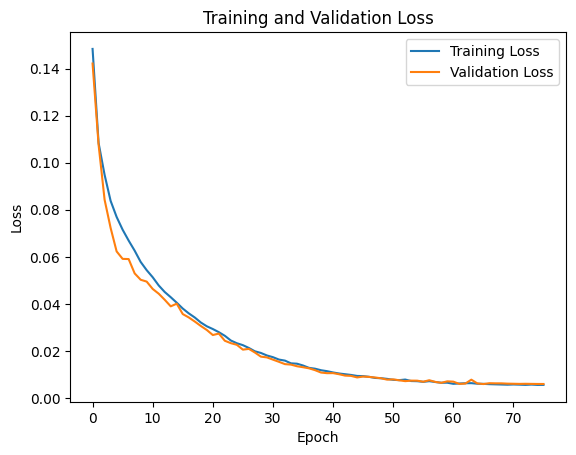

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.8819549000190113
MAE: 0.047731634028431474
RMSE: 0.0654277448978773
MSE: 0.004280789802421709

--- Training round 3 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1792 - val_loss: 0.1848 - learning_rate: 1.0000e-04
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1038 - val_loss: 0.1448 - learning_rate: 1.0000e-04
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0907 - val_loss: 0.1123 - learning_rate: 1.0000e-04
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0793 - val_loss: 0.0829 - learning_rate: 1.0000e-04
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0760 - val_loss: 0.0759 - learning_rate: 1.0000e-04
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0689 - val_loss: 0.0688 - learning_rate: 1.0000e-04
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0649 - val_loss: 0.0671 - learning_rate: 1.0000e-04
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0621 - val_loss: 0.0656 - learning_rate: 1.0000e-04
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0592 - val_loss: 0.0579 - 

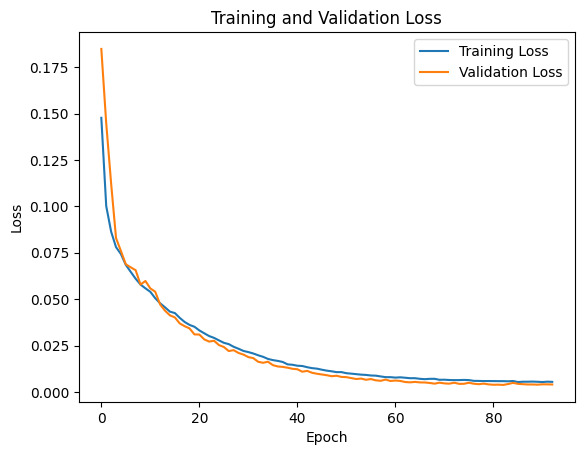

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
R2: 0.8967623297357726
MAE: 0.02917615136872718
RMSE: 0.04902945107895906
MSE: 0.00240388707310404


In [ ]:
models, metrics_list = split_and_train_lstm(X, y, look_back=7, num_splits=3, epochs=100, batch_size=16)

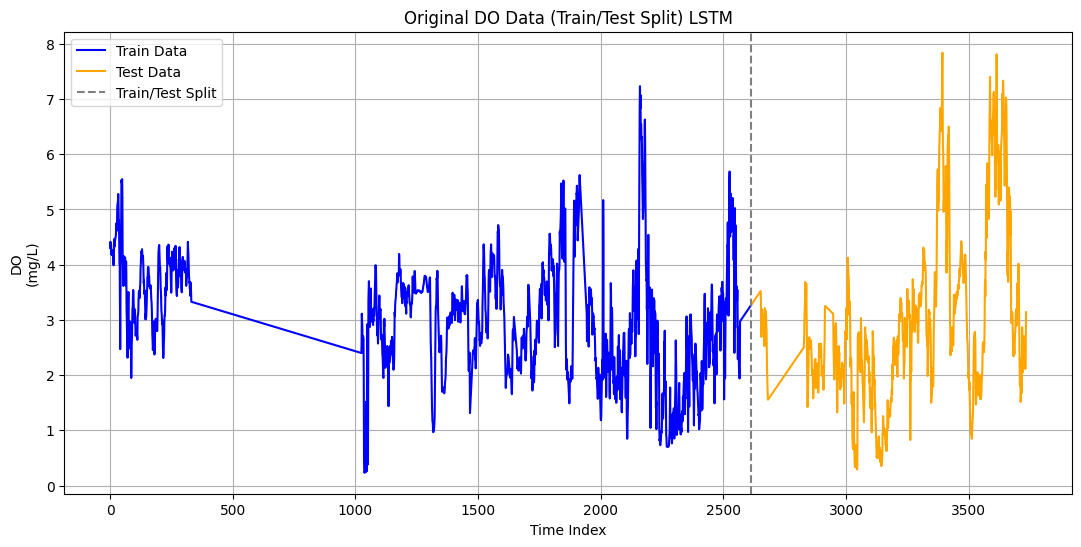

In [ ]:
# กลับค่า y เป็นสเกลจริง
y_inv = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

plt.figure(figsize=(13, 6))

# ข้อมูล Train/Test ที่ใช้ในรอบล่าสุด
split_at = int(len(y) * 0.7)

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(range(split_at), y_train_inv, label="Train Data", color='blue')
plt.plot(range(split_at, len(y_inv)), y_test_inv, label="Test Data", color='orange')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Original DO Data (Train/Test Split) LSTM")
plt.xlabel("Time Index")
plt.ylabel("DO\n(mg/L)")
plt.legend()
plt.grid(True)
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


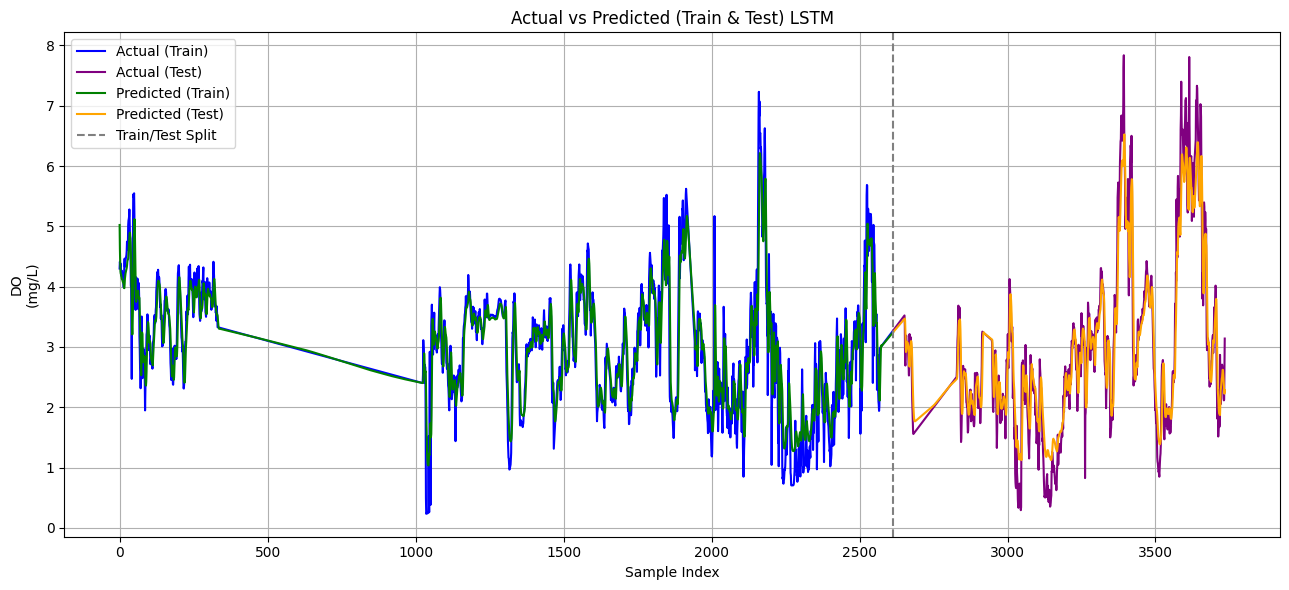

In [ ]:
# ค่าจริงแบบคืนค่าจาก scale
y_all = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

# เลือกโมเดลที่ดีที่สุดจากรายการ
best_model_index = 0  # คุณสามารถเปลี่ยนเป็น 1 หรือ 2 หากต้องการใช้โมเดลอื่น
selected_model = models[best_model_index]

# นำข้อมูลเทรนและเทสจากผลลัพธ์การแบ่งข้อมูลที่มีอยู่แล้ว
# สมมติว่าโค้ดต้นฉบับมีการแบ่งข้อมูลและเก็บไว้ในตัวแปร X_train1 และ X_test1
X_train1 = X[:split_at]
X_test1 = X[split_at:]

# ค่าทำนายช่วงเทรน
y_pred_train = selected_model.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = selected_model.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv

# วาดกราฟ
plt.figure(figsize=(13, 6))

# สร้าง index สำหรับการพล็อต (เนื่องจาก y เป็น numpy array ไม่มี index)
index_range = np.arange(len(y_all))
train_indices = index_range[:split_at]
test_indices = index_range[split_at:]

plt.plot(train_indices, y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(test_indices, y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(train_indices, y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(test_indices, y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) LSTM")
plt.xlabel("Sample Index")
plt.ylabel("DO\n(mg/L)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

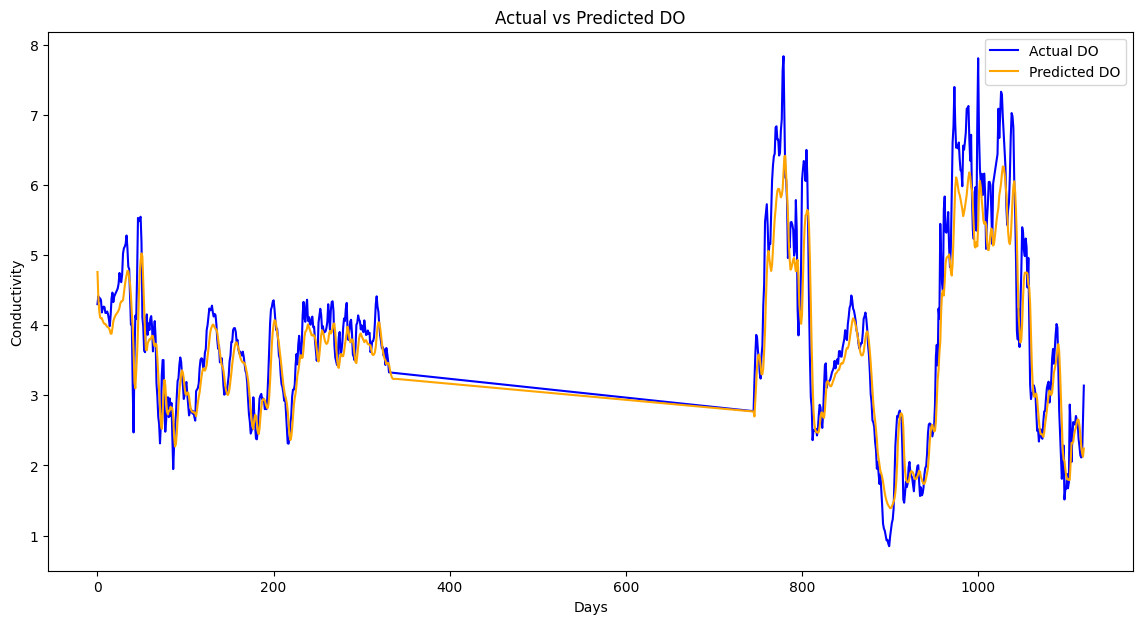

In [ ]:
import matplotlib.pyplot as plt
predictions_last_model = metrics_list[-1]['predictions']
y_test_last_model = metrics_list[-1]['y_test']
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model.reshape(-1, 1))
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual DO', color='blue')
plt.plot(predictions_last_model, label='Predicted DO', color='orange')
plt.title('Actual vs Predicted DO')
plt.xlabel('Days')
plt.ylabel('Conductivity')
plt.legend()
plt.show()

# **pH**

In [ ]:
def train_and_evaluate_lstm(X_train, y_train, X_test, y_test, look_back, epochs=100, batch_size=16):

    # สร้างโมเดล LSTM
    model = Sequential()


    # LSTM ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(LSTM(200, return_sequences=True, input_shape=(look_back, 1),
                   kernel_regularizer=regularizers.l2(0.001)))  # L2 Regularization
    model.add(Dropout(0.4))

    # Batch Normalization หลังจาก LSTM ชั้นแรก
    model.add(BatchNormalization())

    # LSTM ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(LSTM(150, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.4))

     # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.3))


    model.add(Dense(1))  # Output layer
    optimizer = RMSprop(learning_rate=0.001)
    model.compile(optimizer='adam', loss='mean_squared_error')

    # เพิ่ม EarlyStopping เพื่อตรวจจับการ overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()


    predictions = model.predict(X_test)


    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")
    #print(f"y_test: {y_test}")
    #print(f"predictions: {predictions}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics

In [ ]:
zero_counts = (df == 3.080000).sum()
print(zero_counts)

Temperature\n(֯C)         0
Conductivity\n(uS/cm)     0
DO\n(mg/L)                0
pH                       14
dtype: int64


In [ ]:
 df= df.replace(3.080000, np.nan)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),0
DO\n(mg/L),0
pH,0


In [ ]:
df = df[df['pH'] >= 4]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['pH']])

In [ ]:
data_scaled

array([[1.        ],
       [0.95246221],
       [0.8840078 ],
       ...,
       [0.31924468],
       [0.37011809],
       [0.        ]])

In [ ]:
look_back = 7
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [ ]:
df.describe()

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,3726.000000,3726.000000,3726.000000,3726.000000
mean,30.077333,501.800822,2.966926,7.254912
std,1.605338,360.000706,1.114613,0.205745
min,20.238053,164.506944,0.233403,4.419900
25%,29.152187,318.136576,2.333420,7.162153
50%,30.198879,386.746528,2.910165,7.262303
75%,31.237439,541.338542,3.472274,7.340608
max,34.226458,4057.263889,7.837917,9.276510



--- Training round 1 ---
Training data size: (2603, 7, 1), Testing data size: (1116, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.3441 - val_loss: 0.3051
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1458 - val_loss: 0.1784
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0820 - val_loss: 0.0897
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0528 - val_loss: 0.0436
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0358 - val_loss: 0.0256
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0251 - val_loss: 0.0170
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0176 - val_loss: 0.0124
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0129 - val_loss: 0.0079
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0098 - val_loss: 0.0059
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0073 - val_loss: 0.0044
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0058 - val_loss: 0.0034
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0043 -

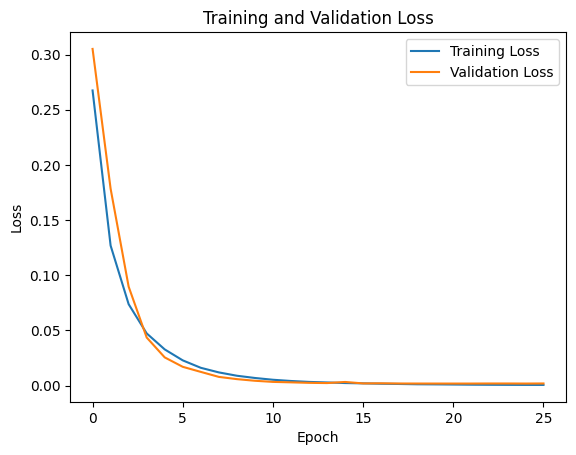

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
R2: 0.526897008500356
MAE: 0.01891045919680385
RMSE: 0.040951916635437825
MSE: 0.0016770594761158495

--- Training round 2 ---
Training data size: (2603, 7, 1), Testing data size: (1116, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3476 - val_loss: 0.3199
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1518 - val_loss: 0.1928
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0882 - val_loss: 0.1222
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0554 - val_loss: 0.0663
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0360 - val_loss: 0.0363
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0248 - val_loss: 0.0199
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0182 - val_loss: 0.0136
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0130 - val_loss: 0.0086
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0098 - val_loss: 0.0065
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0073 - val_loss: 0.0049
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0055 - val_loss: 0.0038
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0044 

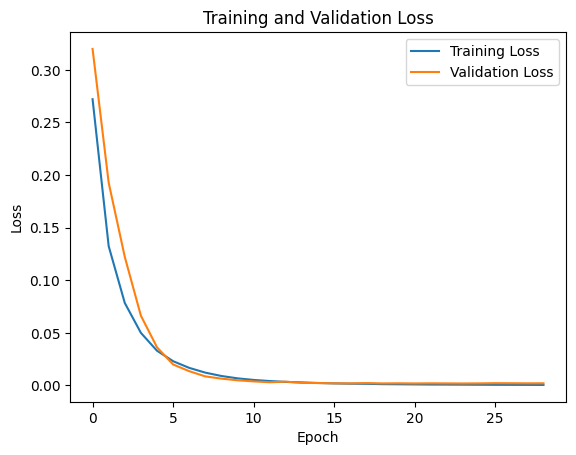

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
R2: 0.5504919071288847
MAE: 0.01798756342895512
RMSE: 0.04122407034015658
MSE: 0.0016994239754101774

--- Training round 3 ---
Training data size: (2603, 7, 1), Testing data size: (1116, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3351 - val_loss: 0.3130
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1435 - val_loss: 0.2093
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0802 - val_loss: 0.1302
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0510 - val_loss: 0.0743
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0328 - val_loss: 0.0317
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0226 - val_loss: 0.0157
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0159 - val_loss: 0.0103
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0109 - val_loss: 0.0094
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0085 - val_loss: 0.0058
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0067 - val_loss: 0.0053
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - val_loss: 0.0033
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.004

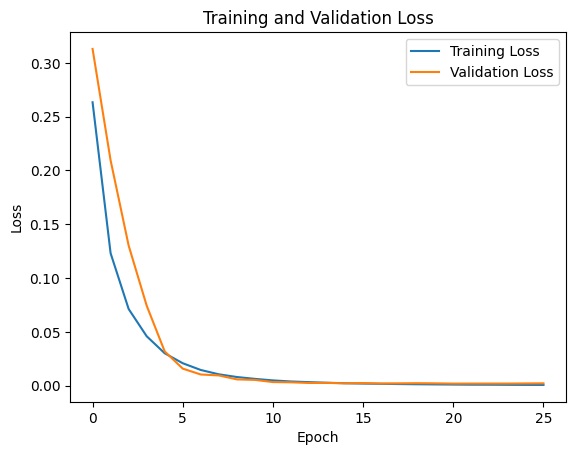

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.5421124624465539
MAE: 0.01680103108600665
RMSE: 0.04080945255711376
MSE: 0.0016654114180113188


In [ ]:
models, metrics_list = split_and_train_lstm(X, y, look_back=7, num_splits=3, epochs=100, batch_size=32)

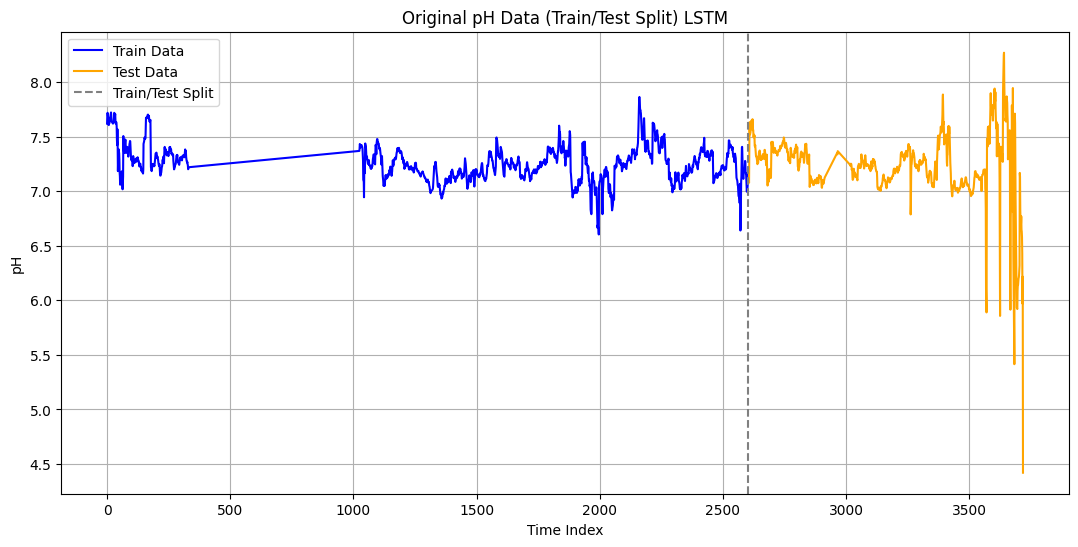

In [ ]:
# กลับค่า y เป็นสเกลจริง
y_inv = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

plt.figure(figsize=(13, 6))

# ข้อมูล Train/Test ที่ใช้ในรอบล่าสุด
split_at = int(len(y) * 0.7)

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(range(split_at), y_train_inv, label="Train Data", color='blue')
plt.plot(range(split_at, len(y_inv)), y_test_inv, label="Test Data", color='orange')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Original pH Data (Train/Test Split) LSTM")
plt.xlabel("Time Index")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


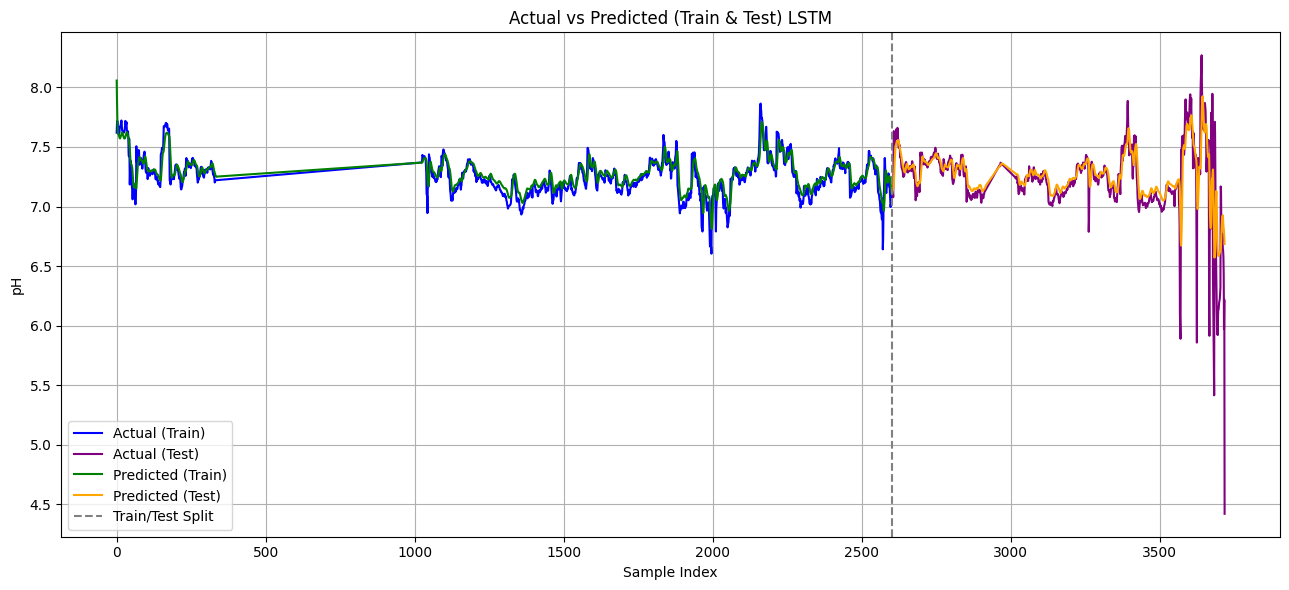

In [ ]:
# ค่าจริงแบบคืนค่าจาก scale
y_all = scaler.inverse_transform(y.reshape(-1, 1)).ravel()

# เลือกโมเดลที่ดีที่สุดจากรายการ
best_model_index = 0  # คุณสามารถเปลี่ยนเป็น 1 หรือ 2 หากต้องการใช้โมเดลอื่น
selected_model = models[best_model_index]

# นำข้อมูลเทรนและเทสจากผลลัพธ์การแบ่งข้อมูลที่มีอยู่แล้ว
# สมมติว่าโค้ดต้นฉบับมีการแบ่งข้อมูลและเก็บไว้ในตัวแปร X_train1 และ X_test1
X_train1 = X[:split_at]
X_test1 = X[split_at:]

# ค่าทำนายช่วงเทรน
y_pred_train = selected_model.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = selected_model.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv

# วาดกราฟ
plt.figure(figsize=(13, 6))

# สร้าง index สำหรับการพล็อต (เนื่องจาก y เป็น numpy array ไม่มี index)
index_range = np.arange(len(y_all))
train_indices = index_range[:split_at]
test_indices = index_range[split_at:]

plt.plot(train_indices, y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(test_indices, y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(train_indices, y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(test_indices, y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=split_at, color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) LSTM")
plt.xlabel("Sample Index")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()